In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib

In [2]:
X_train = np.load("../data/X_train.npy")

df = pd.read_csv("../data/ssd_data.csv")

scaler = joblib.load("../models/scaler.pkl")

In [4]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(X_train)

X_all = scaler.transform(
    df[[
        "temperature",
        "wear_level",
        "power_on_hours",
        "write_cycles",
        "ECC_error_rate",
        "bad_blocks"
    ]]
)

anomaly_labels = iso.predict(X_all)

df["anomaly"] = anomaly_labels

n_anom = (anomaly_labels == -1).sum()

print(f"Anomalies: {n_anom}")
print(f"Percentage: {n_anom/len(df)*100:.1f}%")

Anomalies: 416
Percentage: 5.2%


In [5]:
print(
    df[df["anomaly"] == -1][
        ["wear_level","ECC_error_rate","bad_blocks"]
    ].describe()
)

       wear_level  ECC_error_rate  bad_blocks
count  416.000000      416.000000  416.000000
mean    50.734615        0.056385    3.024038
std     33.581779        0.039765    2.272815
min      0.000000        0.000000    0.000000
25%     16.600000        0.022675    1.000000
50%     50.300000        0.055150    3.000000
75%     84.200000        0.085325    5.000000
max     99.900000        0.184100    9.000000


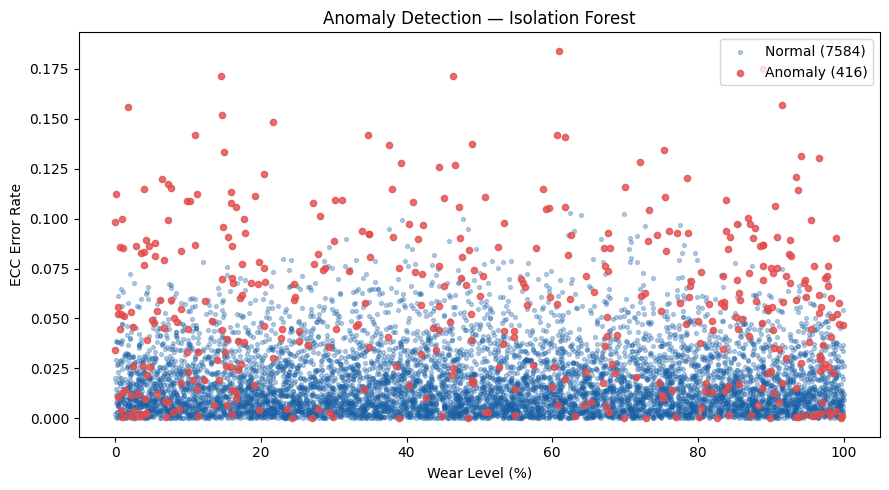

In [6]:
import matplotlib.pyplot as plt

normal = df[df["anomaly"] == 1]
anom   = df[df["anomaly"] == -1]

plt.figure(figsize=(9, 5))

plt.scatter(
    normal["wear_level"],
    normal["ECC_error_rate"],
    alpha=0.3,
    s=8,
    label=f"Normal ({len(normal)})",
    color="#185FA5"
)

plt.scatter(
    anom["wear_level"],
    anom["ECC_error_rate"],
    alpha=0.8,
    s=20,
    label=f"Anomaly ({len(anom)})",
    color="#E24B4A"
)

plt.xlabel("Wear Level (%)")
plt.ylabel("ECC Error Rate")
plt.title("Anomaly Detection — Isolation Forest")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/anomaly_scatter.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

In [7]:
joblib.dump(iso, "../models/anomaly_detector.pkl")
print("Anomaly detector saved.")

Anomaly detector saved.
